In [ ]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

score_path = Path("/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_123/score_results.json")
with open(score_path, "r", encoding="utf-8") as f:
    data = json.load(f)

image_difficulties = data["image_difficulties"]
if not image_difficulties:
    raise ValueError(f"Empty image_difficulties in {score_path}")

obj_sizes = []
obj_scores = []
for img in image_difficulties:
    for obj in img.get("objects_score", []):
        bbox = obj.get("bounding_box", {})
        w = bbox.get("width")
        h = bbox.get("height")
        s = obj.get("difficulty_score")
        if w is None or h is None or s is None:
            continue
        obj_sizes.append(float(w) * float(h))
        obj_scores.append(float(s))

obj_sizes = np.asarray(obj_sizes, dtype=float)
obj_scores = np.asarray(obj_scores, dtype=float)
img_scores = np.asarray([float(img.get("difficulty_score", 0.0)) for img in image_difficulties], dtype=float)
fp_rates = np.asarray([float(img.get("false_positive_rate", np.nan)) for img in image_difficulties], dtype=float)
miss_rates = np.asarray([float(img.get("missed_detections_rate", np.nan)) for img in image_difficulties], dtype=float)

print(f"Loaded scoring file: {score_path}")
print(f"Images: {len(image_difficulties)}")
print(f"Objects: {len(obj_scores)}")


def rankdata(arr):
    arr = np.asarray(arr)
    order = np.argsort(arr)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(arr), dtype=float)
    vals, inv, counts = np.unique(arr, return_inverse=True, return_counts=True)
    for i, c in enumerate(counts):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()
    return ranks + 1.0


def resolve_image_path(path_str):
    if not path_str:
        return None
    p = Path(path_str)
    if p.exists():
        return p
    stem = p.stem
    image_roots = [
        Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images"),
        Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/val/images"),
        Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images"),
    ]
    for root in image_roots:
        for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            candidate = root / f"{stem}{ext}"
            if candidate.exists():
                return candidate
    return None


def draw_bbox(ax, bbox, img_w, img_h, color="red"):
    x_c = bbox.get("x_center")
    y_c = bbox.get("y_center")
    w = bbox.get("width")
    h = bbox.get("height")
    if x_c is None or y_c is None or w is None or h is None:
        return
    bw = float(w) * img_w
    bh = float(h) * img_h
    x0 = float(x_c) * img_w - bw / 2.0
    y0 = float(y_c) * img_h - bh / 2.0
    ax.add_patch(patches.Rectangle((x0, y0), bw, bh, linewidth=2, edgecolor=color, facecolor="none"))


Loaded scoring file: /home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_123/score_results.json
Number of images: 536
Object samples: 22815
Images with FP rate: 536
Images with miss rate: 536


Object scores: count=22815, mean=0.2274, median=0.1729, std=0.1641
Image scores: count=536, mean=0.2329, median=0.2177, std=0.0703


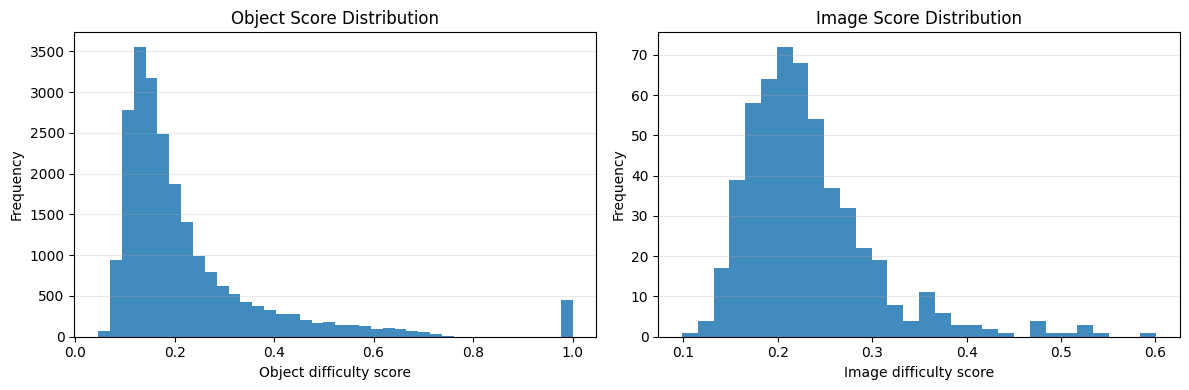

In [13]:
# Score distribution for object and image scores
if len(obj_scores) == 0:
    raise ValueError('No object scores available.')
if len(img_scores) == 0:
    raise ValueError('No image scores available.')

print(f'Object scores: count={len(obj_scores)}, mean={np.mean(obj_scores):.4f}, median={np.median(obj_scores):.4f}, std={np.std(obj_scores):.4f}')
print(f'Image scores: count={len(img_scores)}, mean={np.mean(img_scores):.4f}, median={np.median(img_scores):.4f}, std={np.std(img_scores):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(obj_scores, bins=40, alpha=0.85)
axes[0].set_xlabel('Object difficulty score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Object Score Distribution')
axes[0].grid(axis='y', alpha=0.25)

axes[1].hist(img_scores, bins=30, alpha=0.85)
axes[1].set_xlabel('Image difficulty score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Image Score Distribution')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

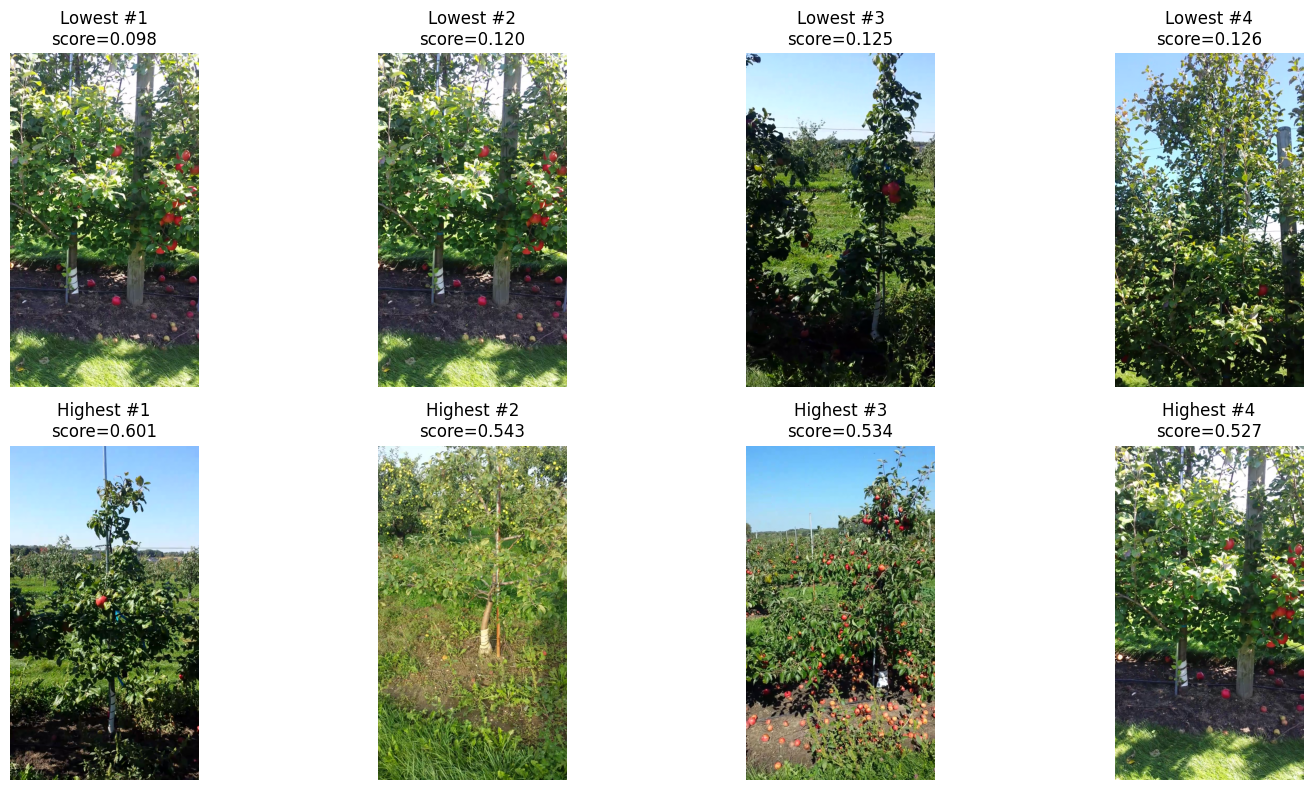

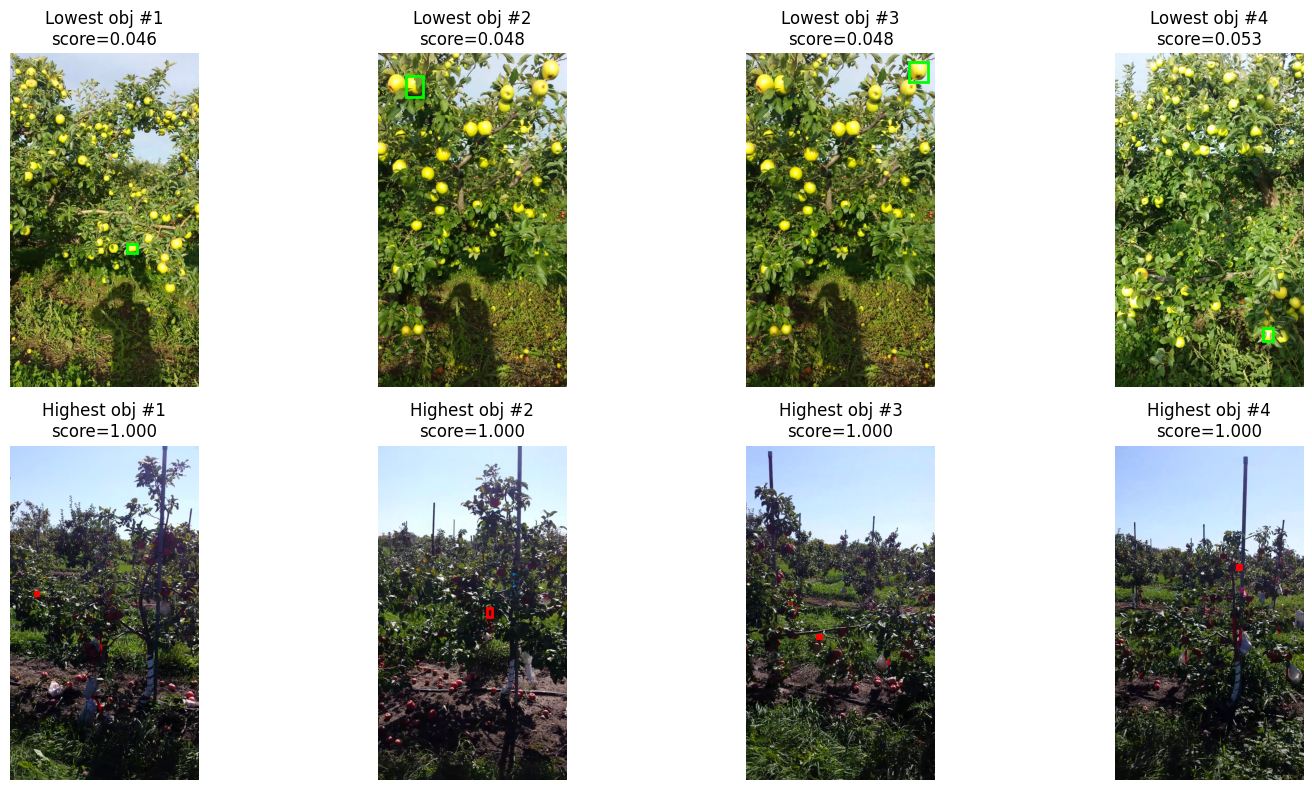

In [14]:
# Visualization of highest and lowest scores for images and objects
k = 4

sorted_imgs = sorted(image_difficulties, key=lambda x: float(x.get('difficulty_score', 0.0)))
lowest_imgs = sorted_imgs[:k]
highest_imgs = sorted_imgs[-k:][::-1]

fig, axes = plt.subplots(2, k, figsize=(4 * k, 8))
for col, item in enumerate(lowest_imgs):
    ax = axes[0, col]
    img_path = resolve_image_path(item.get('image_path', ''))
    if img_path is None:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        ax.axis('off')
        continue
    im = Image.open(img_path).convert('RGB')
    ax.imshow(im)
    ax.set_title(f'Lowest #{col + 1}\nscore={float(item.get("difficulty_score", 0.0)):.3f}')
    ax.axis('off')

for col, item in enumerate(highest_imgs):
    ax = axes[1, col]
    img_path = resolve_image_path(item.get('image_path', ''))
    if img_path is None:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        ax.axis('off')
        continue
    im = Image.open(img_path).convert('RGB')
    ax.imshow(im)
    ax.set_title(f'Highest #{col + 1}\nscore={float(item.get("difficulty_score", 0.0)):.3f}')
    ax.axis('off')

axes[0, 0].set_ylabel('Lowest image scores', fontsize=11)
axes[1, 0].set_ylabel('Highest image scores', fontsize=11)
plt.tight_layout()
plt.show()

all_objects = []
for img in image_difficulties:
    img_path = img.get('image_path', '')
    for obj in img.get('objects_score', []):
        all_objects.append({
            'image_path': obj.get('image_path', img_path),
            'score': float(obj.get('difficulty_score', 0.0)),
            'bbox': obj.get('bounding_box', {}),
        })

if not all_objects:
    raise ValueError('No object-level entries found in image_difficulties.')

all_objects = sorted(all_objects, key=lambda x: x['score'])
lowest_objs = all_objects[:k]
highest_objs = all_objects[-k:][::-1]

fig, axes = plt.subplots(2, k, figsize=(4 * k, 8))
for col, item in enumerate(lowest_objs):
    ax = axes[0, col]
    img_path = resolve_image_path(item['image_path'])
    if img_path is None:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        ax.axis('off')
        continue
    im = Image.open(img_path).convert('RGB')
    w, h = im.size
    ax.imshow(im)
    draw_bbox(ax, item['bbox'], w, h, color='lime')
    ax.set_title(f'Lowest obj #{col + 1}\nscore={item["score"]:.3f}')
    ax.axis('off')

for col, item in enumerate(highest_objs):
    ax = axes[1, col]
    img_path = resolve_image_path(item['image_path'])
    if img_path is None:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        ax.axis('off')
        continue
    im = Image.open(img_path).convert('RGB')
    w, h = im.size
    ax.imshow(im)
    draw_bbox(ax, item['bbox'], w, h, color='red')
    ax.set_title(f'Highest obj #{col + 1}\nscore={item["score"]:.3f}')
    ax.axis('off')

axes[0, 0].set_ylabel('Lowest object scores', fontsize=11)
axes[1, 0].set_ylabel('Highest object scores', fontsize=11)
plt.tight_layout()
plt.show()

Pearson(image_score, missed_detections_rate): 0.6788
Spearman(image_score, missed_detections_rate): 0.6675


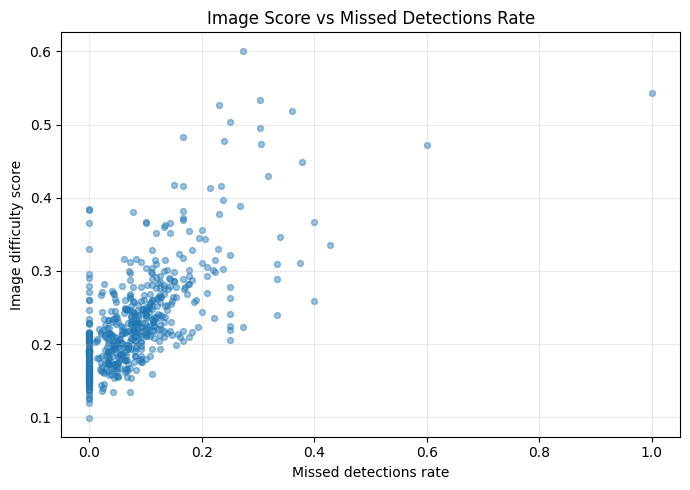

In [15]:
# Correlation: image score vs missed detections rate
valid_miss = ~np.isnan(miss_rates)
if np.sum(valid_miss) < 2:
    raise ValueError('Not enough valid missed_detections_rate values.')

x_miss = miss_rates[valid_miss]
y_miss = img_scores[valid_miss]
pearson_miss = float(np.corrcoef(x_miss, y_miss)[0, 1]) if not (np.allclose(x_miss, x_miss[0]) or np.allclose(y_miss, y_miss[0])) else float('nan')
spearman_miss = float(np.corrcoef(rankdata(x_miss), rankdata(y_miss))[0, 1])

print(f'Pearson(image_score, missed_detections_rate): {pearson_miss:.4f}')
print(f'Spearman(image_score, missed_detections_rate): {spearman_miss:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(x_miss, y_miss, s=18, alpha=0.45)
plt.xlabel('Missed detections rate')
plt.ylabel('Image difficulty score')
plt.title('Image Score vs Missed Detections Rate')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Pearson(image_score, false_positive_rate): 0.6983
Spearman(image_score, false_positive_rate): 0.6463


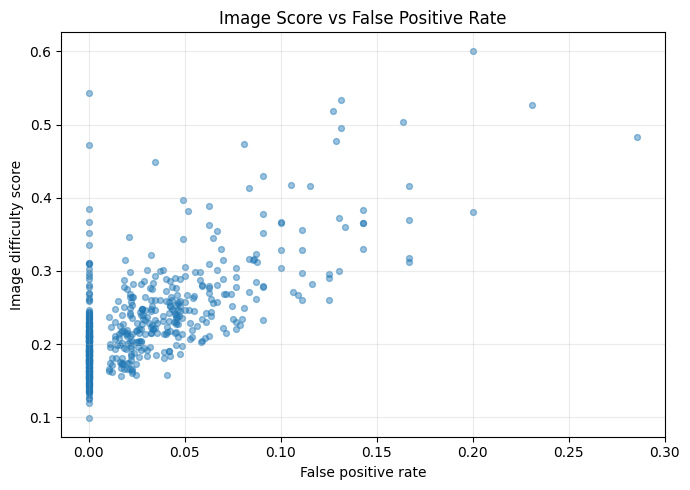

In [16]:
# Correlation: image score vs false positive rate
valid_fp = ~np.isnan(fp_rates)
if np.sum(valid_fp) < 2:
    raise ValueError('Not enough valid false_positive_rate values.')

x_fp = fp_rates[valid_fp]
y_fp = img_scores[valid_fp]
pearson_fp = float(np.corrcoef(x_fp, y_fp)[0, 1]) if not (np.allclose(x_fp, x_fp[0]) or np.allclose(y_fp, y_fp[0])) else float('nan')
spearman_fp = float(np.corrcoef(rankdata(x_fp), rankdata(y_fp))[0, 1])

print(f'Pearson(image_score, false_positive_rate): {pearson_fp:.4f}')
print(f'Spearman(image_score, false_positive_rate): {spearman_fp:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(x_fp, y_fp, s=18, alpha=0.45)
plt.xlabel('False positive rate')
plt.ylabel('Image difficulty score')
plt.title('Image Score vs False Positive Rate')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()